# Portfolio Value at Risk: Historical, Parametric, Monte Carlo and Bayesian Methods



When you hold a portfolio of assets, one of the most basic — and most important — questions you can ask is: *how much could I lose?* Value at Risk (VaR) answers this in a precise way: at a given confidence level (say, 95%), it estimates the maximum loss you'd expect over a given time horizon under normal market conditions.



This is not just an academic exercise. VaR is the standard risk metric used by banks, hedge funds, and regulators to size positions, set capital requirements, and decide how much risk is acceptable. But *how* you estimate it matters a lot — different methods make different assumptions, and those assumptions can lead to very different (and sometimes dangerously wrong) answers.



In this notebook, we compute the VaR of a 4-asset equity portfolio using four different approaches:



- **Historical VaR** — reads the risk directly from past data, with no distributional assumptions.

- **Parametric VaR** — assumes returns follow a log-normal model and derives VaR analytically.

- **Monte Carlo VaR** — simulates thousands of possible futures under the same model, without approximating the portfolio's distribution as normal.

- **Bayesian VaR** —  goes beyond the standard toolkit by also accounting for parameter uncertainty: how confident can we really be in our estimates of expected return and volatility, given the amount of data we have? 



We then go one step further and use the same modeling framework to solve the **Markowitz portfolio problem**: given these estimates, what portfolio weights minimize risk for a target expected return?



The full mathematical derivation behind each method is available in [`MATH.md`](../MATH.md); here, we focus on running the methods on real market data and interpreting what they tell us — including a key finding on how the amount of historical data available changes how much we should trust our own estimates.





*Note: while historical, parametric, and Monte Carlo VaR are standard industry methods, so is the Bayesian approach used here — the classical Normal-Inverse-Wishart posterior predictive method, implemented from scratch in this project, and aimed at explicitly quantifying parameter uncertainty, something the other three methods cannot do.*

### First, we select the tickers and the time period

In [1]:
import sys
sys.path.append("../src")

from data_loader import download_prices

tickers = ["YPF", "GGAL", "BMA", "PAM", "AGRO", "BIOX"]
period = "1y"
data_location = "../data/precios.csv"

prices = download_prices(tickers,period)
prices.to_csv(data_location)

[*********************100%***********************]  6 of 6 completed


### We use the class **FinancialContext** to manage the data

In [2]:
sys.path.append("../src")
from var_methods import FinancialContext

data_location = "../data/precios.csv"

fc = FinancialContext(data_location)

## Value at Risk: four methods, one portfolio 

We now compute the VaR of our portfolio using the four methods derived in

[`MATH.md`](../MATH.md), on the same uniform portfolio, at a 1-day horizon

and 95% confidence level. Each method makes different assumptions about how

returns behave — comparing them side by side is the core of this analysis.

 

We start by defining a uniform portfolio: an equal dollar amount invested

in each of the 6 tickers.



In [3]:
import numpy as np
 
portfolio = np.ones(6) #we have equal weights invested on the firms

### Historical VaR

 

Reads the risk directly from the empirical distribution of past portfolio

P&L, with no assumption on the shape of returns — only that the past is

representative of the future (see [`MATH.md`, Historical VaR](../MATH.md#historical-var)).



historical-VaR: 3.8%


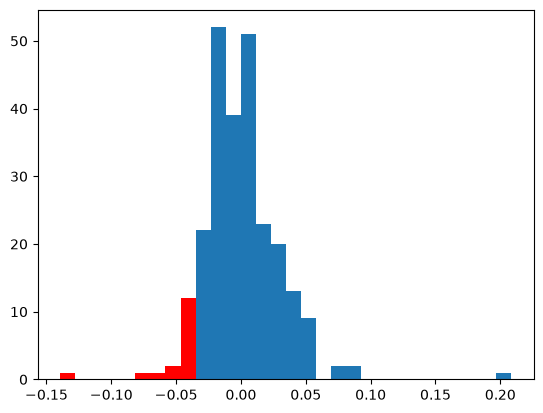

In [4]:
var_hist = fc.historical_VaR(portfolio, horizon=1, alpha=0.05, plot=True)

### Parametric VaR

 

Models the portfolio's log-returns as multivariate normal and derives VaR

analytically from the resulting mean and standard deviation of the

portfolio's value (see [`MATH.md`, Parametric approach](../MATH.md#parametric-approach)).



parametric-VaR: 4.9%


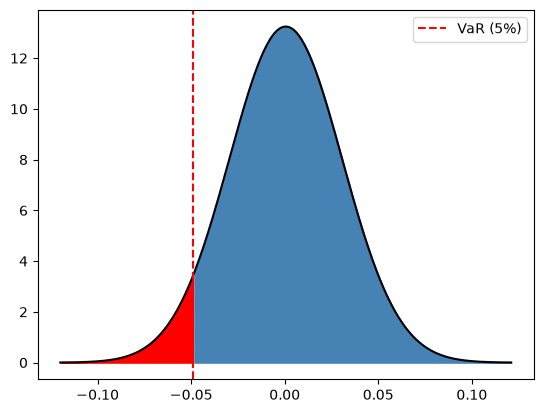

In [5]:
var_param = fc.parametric_VaR(portfolio, horizon=1, alpha=0.05, plot=True)

### Monte Carlo VaR

 

Simulates thousands of possible portfolio outcomes under the same

log-normal model, without approximating the portfolio's own distribution

as normal — this lets us check how good that normal approximation really

is (see [`MATH.md`, Montecarlo approach](../MATH.md#monte-carlo-approach)).



montecarlo-VaR: 4.8%


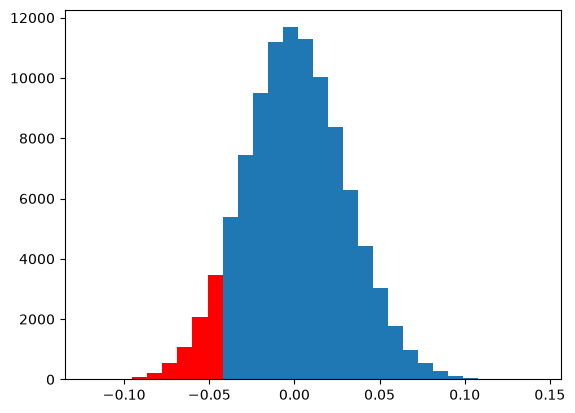

In [6]:
var_mc = fc.montecarlo_VaR(portfolio, horizon=1, alpha=0.05, N=100_000, plot=True)

### Bayesian VaR

 

Goes a step further than the previous three methods: instead of treating

the estimated mean and covariance as fixed, it treats them as uncertain,

via a Normal-Inverse-Wishart posterior, and integrates over that

uncertainty when simulating outcomes *(a classical Bayesian method,

implemented from scratch in this project — see

[`MATH.md`, Bayesian VaR](../MATH.md#bayesian-var))*.



bayesian-VaR: 4.87%


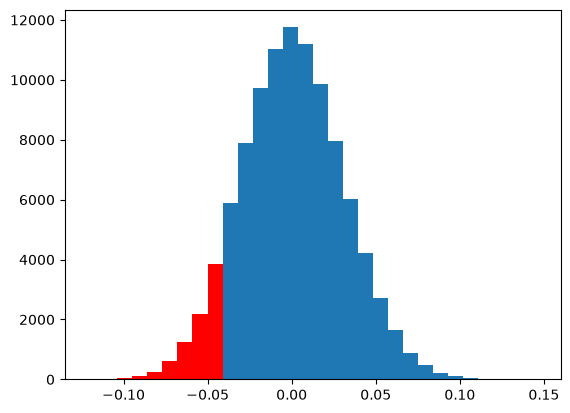

In [7]:
var_bayes = fc.bayesian_VaR(portfolio, horizon=1, alpha=0.05, N=100_000, plot=True)

In [8]:
import pandas as pd
 
comparison = pd.Series({
    "Historical": var_hist,
    "Parametric": var_param,
    "Monte Carlo": var_mc,
    "Bayesian": var_bayes,
}, name="1-day VaR (95%)")
 
(comparison * 100).round(2).astype(str) + "%"


Historical      3.8%
Parametric      4.9%
Monte Carlo     4.8%
Bayesian       4.87%
Name: 1-day VaR (95%), dtype: str

### Why do parametric, Monte Carlo, and Bayesian agree so closely?



These three methods are not independent ideas — they are three different

*computational strategies* for the same underlying model: log-returns

following a multivariate normal distribution (see

[`MATH.md`](../MATH.md)). The parametric method solves for this model's

implications in closed form; Monte Carlo solves it by simulation instead

of algebra; and the Bayesian method solves essentially the same simulation,

but additionally samples over parameter uncertainty. Since all three start

from the *same phenomenological assumption* about how the market behaves,

it would be surprising — and a sign of a bug — if they gave very different

answers. Their agreement here is a consistency check on the implementation

as much as it is a finding about the market.



### Why is the historical VaR the *lowest* of the four here?



Interestingly, the historical estimate here comes out **lower** than the

three model-based methods — rather than higher, which might be the more

intuitive expectation. This is not a bug; it reflects a real, and somewhat

counterintuitive, effect of outliers on Gaussian-based models.

 

When we fit a normal distribution (or any similarly shaped model) to a

return series that contains a few large outliers those outliers pull the fitted standard deviation upward

disproportionately, since variance weighs large deviations quadratically.

The result is a fitted "bell curve" that is wider than what the *bulk* of

the data would suggest on its own, because the fit is forced to also

accommodate a handful of extreme days.

 

Since the parametric, Monte Carlo, and Bayesian methods all rely on this

same fitted covariance structure (Eq. P.1–P.5 in `MATH.md`), an inflated

standard deviation propagates directly into an inflated VaR — a

conservative bias, but one driven by the model's sensitivity to outliers

rather than by the true shape of typical daily risk. The historical

method, by contrast, reads the 5th percentile directly from the empirical

sample: a handful of extreme days pull the *tail* of the distribution, but

they don't distort the *whole* distribution's spread the way they do when

forced into a symmetric Gaussian fit. This is why it lands lower here.

 



**A natural extension**: since this behavior comes from the well-known

sensitivity of Gaussian fits to outliers, a promising next step would be

to replace the log-normal return model with one based on the **Cauchy

distribution** — a heavy-tailed distribution with no finite variance,

widely used in finance precisely because its parameter estimates are far

more robust to outliers than the normal distribution's. This is left as

future work for this project.



### Why is the Bayesian estimate so close to the parametric and Monte Carlo values, yet still the most conservative?



With a full year of daily data (~250 observations), our estimates of the

mean and covariance of returns are already fairly precise — there simply

isn't that much residual uncertainty left to account for. This is why the

Bayesian VaR lands so close to the parametric and Monte Carlo values: the

posterior over $\mu$ and $\Sigma$ is tight, and sampling from it looks a

lot like using the fixed point estimates the other methods rely on.



But "tight" is not the same as "zero". The Bayesian method is the only one

of the four that explicitly propagates the fact that $\mu$ and $\Sigma$

are themselves estimated from a finite sample, not known exactly — and

that residual uncertainty, however small, only ever adds risk, never

subtracts it. This is why the Bayesian VaR consistently comes out as the

most conservative of the three model-based methods, even with abundant

data: it is answering a subtly different, more honest question — not

*"what is the risk under my best point estimate of the market?"*, but

*"what is the risk, given everything I don't know about my own estimate?"*

## The key experiment: how much data changes what we know

 

All four methods above were computed using a full year of daily prices.

But how would each estimate change if we had *less* history to work with?

In particular, does the Bayesian method's promise — that it should widen

its estimate when there's less data to support it — actually hold up?

 

To find out, we repeat the full pipeline (download → build the financial

context → compute VaR) using between 1 and 12 months of historical data,

and track how each of the four VaR estimates evolves as the sample grows.



In [20]:
import sys
sys.path.append("../src")
 
import numpy as np
import pandas as pd
 
from data_loader import download_prices
from var_methods import FinancialContext


horizon = 100
N = 10000
months_range = range(1, 13)
var_results = {"Historical": [], "Parametric": [], "Monte Carlo": [], "Bayesian": []}
 
for m in months_range:
    period = f"{m}mo"
 
    prices_m = download_prices(period=period)
    path = f"../data/precios_{m}mo.csv"
    prices_m.to_csv(path)
 
    fc_m = FinancialContext(path)
    portfolio = np.array([25_000] * fc_m.N_tickers)
 
    var_results["Historical"].append(fc_m.historical_VaR(portfolio, horizon=horizon, verbose=False, plot=False))
    var_results["Parametric"].append(fc_m.parametric_VaR(portfolio, horizon=horizon, verbose=False, plot=False))
    var_results["Monte Carlo"].append(fc_m.montecarlo_VaR(portfolio, horizon=horizon, N=N, verbose=False, plot=False))
    var_results["Bayesian"].append(fc_m.bayesian_VaR(portfolio, horizon=horizon, N=N, verbose=False, plot=False))
 
results_df = pd.DataFrame(var_results, index=list(months_range))
results_df.index.name = "Months of history"
results_df


[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  5 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  5 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed
[*********************100%***********************]  6 of 6 completed


,Historical,Parametric,Monte Carlo,Bayesian
Months of history,,,,
1,NaN,0.203252,0.112726,0.367409
2,NaN,0.205699,0.166133,0.331127
3,NaN,0.396041,0.360528,0.463733
4,NaN,0.367862,0.316961,0.415685
5,0.102639,0.365351,0.305238,0.391332
6,0.108616,0.289947,0.226493,0.304001
7,0.091796,0.400690,0.346960,0.408516
8,0.084553,0.369120,0.318732,0.365488
9,0.073925,0.367335,0.323547,0.367901


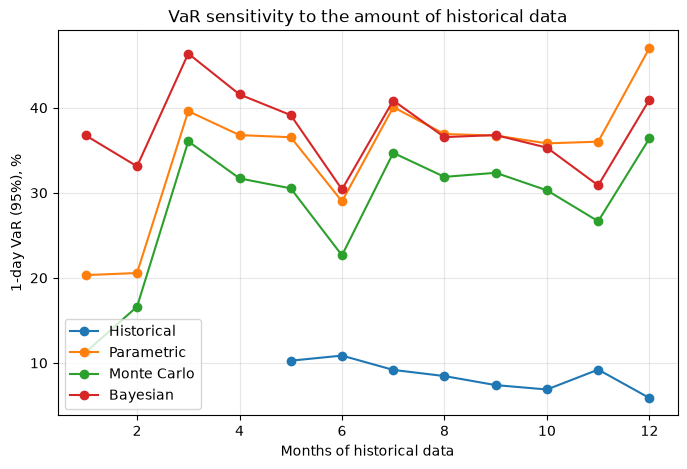

In [21]:
import matplotlib.pyplot as plt
 
plt.figure(figsize=(8, 5))
for method in results_df.columns:
    plt.plot(results_df.index, results_df[method] * 100, marker="o", label=method)
 
plt.xlabel("Months of historical data")
plt.ylabel("1-day VaR (95%), %")
plt.title("VaR sensitivity to the amount of historical data")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


### Reading the result

 

Three patterns stand out:

 

**In the first month, the Bayesian estimate is always the most

conservative.** Checking this across different values of `horizon`

confirms it holds consistently: with only ~21 observations, the posterior

over $\mu$ and $\Sigma$ is wide enough that the Bayesian VaR sits above

every other method, every time. This is exactly what the model predicts —

with this little data, parameter uncertainty is large enough to dominate

the estimate.

 

**From month 2 onward, it becomes a competition between the model-based

methods and the historical method** — with no single method reliably on

top. The Bayesian estimate is no longer guaranteed to be the highest; it

now depends on how the specific sample of returns happened to fall, and on

how that interacts with the historical percentile's own sampling noise.

 

**By around 4 months, parametric, Monte Carlo, and Bayesian have

converged closely to each other**, and from that point on the "competition"

between the four methods becomes largely noise-driven rather than

structural — small month-to-month fluctuations rather than a persistent

ordering. Even so, the Bayesian estimate tends to land at or above the

other two model-based methods more often than not, consistent with the

fact that some parameter uncertainty always remains, however small, and

can only ever push the estimate up, never down.

 

**The historical VaR is the noisiest of the four, not the highest or

lowest.** Unlike the smooth, near-monotonic model-based curves, the

historical estimate jumps around — sometimes below the other three,

sometimes above them, across the whole range. This reflects the

small-sample nature of an empirical percentile: with only a handful of

daily observations in the tail, a single unusually good or bad day can

shift the 5th percentile substantially. This instability is itself a

finding: the historical method's main weakness isn't a *directional*

bias, but a lack of statistical power when the sample window is short —

precisely the gap the Bayesian method is designed to make explicit rather

than hide.

## Finding the best portfolio: Markowitz

 

So far, we've measured the risk of a fixed, uniform portfolio. But a

natural question follows: could we do better? Given estimates of expected

return and risk for each asset, is there a smarter way to combine them?

 

This is exactly the question Harry Markowitz asked in 1952, as a 25-year-old

graduate student at the University of Chicago. His answer — now known as

Modern Portfolio Theory — formalized something investors already knew

intuitively ("don't put all your eggs in one basket") into rigorous

mathematics: by combining assets that don't move in perfect lockstep, an

investor can reduce a portfolio's overall risk without sacrificing expected

return. The paper, titled simply *"Portfolio Selection"*, was published in

the *Journal of Finance* and became the foundation of an entire field.

Nearly four decades later, in 1990, Markowitz shared the Nobel Memorial

Prize in Economic Sciences for this work, alongside Merton Miller and

William Sharpe.

 

The full derivation of the classical Markowitz problem — solved here in

closed form via Lagrange multipliers, rather than numerical optimization —

is available in [`MATH.md`](../MATH.md#finding-the-best-portfolio--the-markowitz-problem).

Below, we compute the optimal portfolio for a target expected return, using

the exact same log-normal model behind our parametric VaR.

 

**A note on the solution**: this closed-form version of the problem does

*not* restrict portfolio weights to be non-negative — the optimizer is free

to assign a negative weight to an asset, which corresponds to a short

position (betting against that asset). This matches the classical 1952

formulation; a long-only constraint (no shorting) would turn this into a

numerical optimization problem instead of an algebraic one.



In [52]:
target_return = 1.15  # target gross portfolio value over the horizon (1.15 = +15% in one year)
 
optimal_weights = fc.markowitz_portfolio(target_return, horizon=365,verbose=False)
 
pd.Series(optimal_weights, index=fc.tickers, name="Optimal weight")


AGRO    0.268554
BIOX    0.319581
BMA     0.003247
GGAL   -0.088930
PAM     0.451268
YPF     0.046279
Name: Optimal weight, dtype: float64

### Reading the optimal portfolio

 

For a 15% annual expected return target, the optimizer suggests:

 

| Asset | Weight |

|---|---|

| PAM  | 45.1%  |

| BIOX | 32.0%  |

| AGRO | 26.9%  |

| YPF  | 4.6%   |

| BMA  | 0.3%   |

| GGAL | **-8.9%** |

 

Two things stand out. The portfolio is far from diversified — nearly 90%

concentrates in PAM, BIOX, and AGRO. And GGAL gets a **negative weight**: a

short position. This doesn't mean the model expects GGAL to fall — since

portfolio variance depends on the full covariance structure (Eq. K.2,

`MATH.md`), shorting an asset correlated with the rest can *reduce*

overall volatility regardless of its own expected return. It's a

volatility-hedging effect, not a directional bet — a genuine feature of

mean-variance optimization.

 

Since we imposed no non-negativity constraint (Eq. K.3, `MATH.md`), the

closed-form solution is free to reach for this kind of position; a

long-only mandate would floor it at zero and require numerical

optimization instead.



## Conclusions



This repository implements a full portfolio risk toolkit from first

principles: four independent VaR methods (historical, parametric, Monte

Carlo, and a Bayesian method built on the classical Normal-Inverse-Wishart model),

a closed-form solution to the classical Markowitz problem, and a

`MATH.md` document deriving every formula used, from the log-normal price

model up to the Bayesian posterior. The four methods aren't just run in

isolation — they're cross-validated against each other, and the

experiment below shows the framework doing exactly what the theory

predicts when the data available to it changes.



- **Parametric, Monte Carlo, and Bayesian VaR agree closely** — expected,

  since all three interpret market dynamics through the same log-normal

  model; only *how* they compute the answer differs.

- **The Bayesian method is consistently the

  most conservative** among the three, and this effect is strongest with

  little data: with 1 month of history it clearly stands above the rest;

  from ~4 months onward the gap narrows into noise, though Bayesian still

  tends to sit at or above the others.



**Limitations**: every model here assumes log-returns are multivariate

normal and i.i.d. over time; the historical method instead assumes the

past is representative of the future. Neither assumption is guaranteed to

hold, especially for Argentine equities prone to sharp, news-driven moves.



**Possible next steps**: add CVaR alongside VaR; replace the log-normal

model with a Cauchy-based one, more robust to outliers.

